https://huggingface.co/0hawkeye33/Adapters/tree/main
- sort OOM

In [ ]:
!pip install transformers torchaudio huggingface_hub accelerate pandas matplotlib

In [ ]:
from huggingface_hub import hf_hub_download

# Replace 'your_checkpoint_file.pt' with the exact filename inside the '0hawkeye33/Adapters' repository.
# For example, if it's named 'pytorch_model.pt', use that.
HF_FILENAME = "ISMIR/Adapters_40M/Hindustani/MusicgenMedium_with_adapters_EncoderDecoder_512_CNN.pt"

try:
    model_save_path = hf_hub_download(repo_id="0hawkeye33/Adapters", filename=HF_FILENAME)
    print(f"Success! Model downloaded directly to Colab cache path: {model_save_path}")
except Exception as e:
    print(f"Error downloading file. Make sure the filename is correct: {e}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ISMIR/Adapters_40M/Hindustani/MusicgenMe(…):   0%|          | 0.00/8.54G [00:00<?, ?B/s]

Success! Model downloaded directly to Colab cache path: /root/.cache/huggingface/hub/models--0hawkeye33--Adapters/snapshots/cc2cb10e527d09c845bb64d25e35cc9ca8297512/ISMIR/Adapters_40M/Hindustani/MusicgenMedium_with_adapters_EncoderDecoder_512_CNN.pt


In [ ]:
import torch
import torch.nn as nn
import torchaudio
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import os
import matplotlib.pyplot as plt
import gc

# Configurations
pretrained_model_name = "facebook/musicgen-medium"
sample_rate = 32000
adapter_bottleneck_dim = 512  # Keep matching your training settings
max_new_tokens = 512        # 512 tokens = ~10 seconds of music
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_finetuned_model = True

print(f"Using device: {device}")

# =====================================================================
# CNN Adapter Architecture
# =====================================================================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=7, stride=1, dilation=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size, stride,
            padding=(kernel_size // 2) * dilation, dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.activation = nn.GELU()
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size, stride,
            padding=(kernel_size // 2) * dilation, dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.bn2(x)
        return x + residual

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        batch_size, channels, _ = x.shape
        y = self.global_avg_pool(x).view(batch_size, channels)
        y = self.fc(y).view(batch_size, channels, 1)
        return x * y

class Adapter(nn.Module):
    def __init__(self, bottleneck_channels=192, input_channels=2, seq_len=32000, dropout_prob=0.1):
        super(Adapter, self).__init__()
        self.adapter_down = nn.Sequential(
            nn.Conv1d(input_channels, bottleneck_channels, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(bottleneck_channels),
            nn.GELU()
        )
        self.bottleneck = nn.Sequential(
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=1),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=2),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=4),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=8),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=16),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=32),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=64),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=128),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=256),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=1),
            ResidualBlock(bottleneck_channels, bottleneck_channels, kernel_size=7, dilation=2),
            SEBlock(bottleneck_channels),
            nn.Conv1d(bottleneck_channels, bottleneck_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(bottleneck_channels),
            nn.GELU(),
        )
        self.adapter_up = nn.Sequential(
            nn.Conv1d(bottleneck_channels, input_channels, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(input_channels)
        )
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, residual):
        x = self.adapter_down(residual)
        x = self.bottleneck(x)
        x = self.adapter_up(x)
        return self.dropout(x + residual)

class MusicGenWithAdapters(nn.Module):
    def __init__(self, musicgen_model, processor, adapter_bottleneck_dim=256, device='cpu'):
        super(MusicGenWithAdapters, self).__init__()
        self.musicgen = musicgen_model
        self.adapter = Adapter(bottleneck_channels=adapter_bottleneck_dim, input_channels=2, seq_len=32000).to(device)

    def forward(self, audio_text):
        # 1. Base Generation (Runs in native precision to avoid token corruption)
        encoder_output = self.musicgen.generate(**audio_text, max_new_tokens=max_new_tokens)

        # Ensure standard float32 precision for adapter layers
        encoder_output = encoder_output.float()

        # FIX (Mono to Stereo): Duplicate channels to match what the adapter expects
        if encoder_output.size(1) == 1:
            encoder_output = encoder_output.repeat(1, 2, 1)

        # Move tensor to the adapter's processing device
        target_device = next(self.adapter.parameters()).device
        encoder_output = encoder_output.to(target_device)

        # 2. Post-Process via Finetuned Adapter Layer
        adapted = self.adapter(encoder_output)
        return adapted

# =====================================================================
# Model Loading Helper (Memory-Mapped + Memory-Safe)
# =====================================================================
def load_model(use_finetuned_model, checkpoint_path, device):
    processor = AutoProcessor.from_pretrained(pretrained_model_name)

    if use_finetuned_model:
        print("Loading Fine-Tuned Weights into Architecture Wrapper...")
        musicgen_model = MusicgenForConditionalGeneration.from_pretrained(
            pretrained_model_name,
            low_cpu_mem_usage=True
        ).to(device)

        model_with_adapters = MusicGenWithAdapters(musicgen_model, processor, adapter_bottleneck_dim=adapter_bottleneck_dim, device=device).to(device)

        gc.collect()
        torch.cuda.empty_cache()

        print("Loading 8GB checkpoint file using memory mapping (mmap=True) to save CPU RAM...")
        # FIX: mmap=True maps the weights directly on disk instead of staging them into RAM
        checkpoint = torch.load(checkpoint_path, map_location='cpu', mmap=True)

        print("Injecting weights into MusicGen base layers (strict=False)...")
        # FIX: pop out individual keys and collect garbage immediately to wipe memory footprints
        model_with_adapters.musicgen.load_state_dict(checkpoint.pop('musicgen_state_dict'), strict=False)
        gc.collect()

        print("Injecting weights into Adapter layer...")
        model_with_adapters.adapter.load_state_dict(checkpoint.pop('adapter_state_dict'), strict=False)
        gc.collect()

        del checkpoint
        gc.collect()
        torch.cuda.empty_cache()

        model_with_adapters.eval()
        print("Model successfully loaded onto GPU without overloading VRAM or CPU RAM!")
        return model_with_adapters, processor
    else:
        print("Loading Original Pretrained Model...")
        musicgen_model = MusicgenForConditionalGeneration.from_pretrained(pretrained_model_name).to(device)
        musicgen_model.eval()
        return musicgen_model, processor

# =====================================================================
# Audio Generation Function (Clean Precision Execution)
# =====================================================================
def generate_audio(model, processor, text_prompt, sample_rate=32000):
    input_data = processor(text=[text_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        if isinstance(model, MusicGenWithAdapters):
            generated_output = model(input_data)
        else:
            generated_output = model.generate(**input_data, max_new_tokens=max_new_tokens)

    waveform = generated_output.squeeze(0).cpu().float()

    if sample_rate != 32000:
        resampler = torchaudio.transforms.Resample(orig_freq=32000, new_freq=sample_rate)
        waveform = resampler(waveform)

    return waveform


Using device: cuda


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.87k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/8.04G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/8.04G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/996 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Loading 8GB checkpoint file using memory mapping (mmap=True) to save CPU RAM...
Injecting weights into MusicGen base layers (strict=False)...
Injecting weights into Adapter layer...
Model successfully loaded onto GPU without overloading VRAM or CPU RAM!

Generating fine-tuned audio for: 'An expressive instrumental composition inspired by Raga Bhairavi, featuring traditional Indian classical melody and instruments'
Track completed! Saved to local environment workspace at: ./output_generation.wav


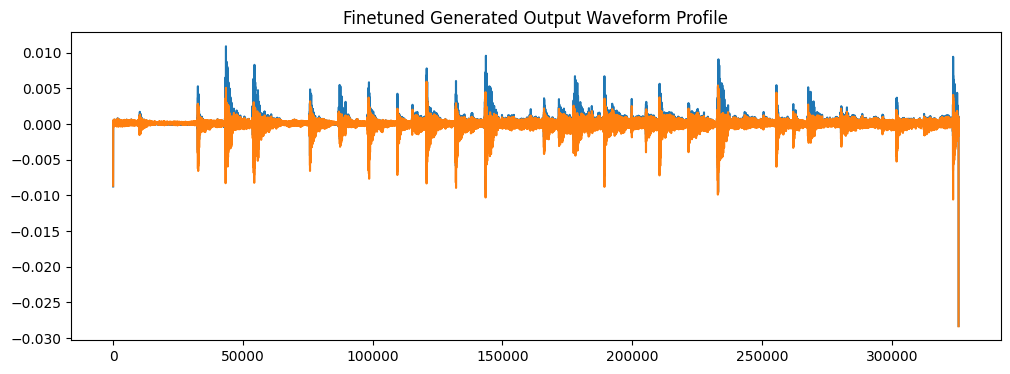

In [ ]:
# =====================================================================
# Inference Execution Room
# =====================================================================
if __name__ == "__main__":
    if 'model_save_path' not in locals() and 'model_save_path' not in globals():
        raise NameError("The variable 'model_save_path' is not defined. Ensure you have run the huggingface_hub download step first!")

    # Flush any leftover memory leaks before loading begins
    gc.collect()
    torch.cuda.empty_cache()

    model, processor = load_model(use_finetuned_model, model_save_path, device)

    # Simple direct testing prompt
    text_prompt = "An expressive instrumental composition inspired by Raga Bhairavi, featuring traditional Indian classical melody and instruments"
    print(f"\nGenerating fine-tuned audio for: '{text_prompt}'")

    waveform = generate_audio(model, processor, text_prompt, sample_rate=sample_rate)

    # Save Output Track
    output_audio_path = "./output_generation.wav"
    torchaudio.save(output_audio_path, waveform, sample_rate)
    print(f"Track completed! Saved to local environment workspace at: {output_audio_path}")

    # Plotting Waveform Graph
    plt.figure(figsize=(12, 4))
    plt.plot(waveform.t().numpy())
    plt.title("Finetuned Generated Output Waveform Profile")
    plt.savefig("./waveform_graph.jpeg")
    plt.show()
    plt.close()